## Module 2: Finding Neutral Atom Qubit Gates
### Exercise 2-3: CZ Gate Fidelity Optimization - Results Analysis

This notebook **visualizes and analyzes the optimization results** from `module2_CZ_gate_fidelity_optimization_multiprocess.py`. 

**Main objectives:**
1. **Investigate the relationship between optimized CZ gate fidelity and Rydberg blockade strength $B$**
   - Understand how gate performance varies with increasing $B$

2. **Analyze how optimized pulse parameters vary with $B$**
   - Track How the optimized Rabi frequency $\Omega_r$ and detuning $\Delta_r$ evolve with Rydberg blockade strength $B$

3. **Examine optimization convergence quality**
   - Verify that optimization successfully converges

**Data source:** Results obtained from multiprocess optimization across multiple $B$ values

In [2]:
import matplotlib.pyplot as plt

# Import custom modules
# Add parent directory to path for myPkg imports
import sys
from pathlib import Path

# For notebooks, use current working directory to find parent
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))
    
from myPkg.optimization_utils import OptimizationMonitor
from myPkg.plotting_helpers import plot_fidelity_vs_parameter, plot_optimization_convergence, plot_parameter_vs_parameter, plt_config
from myPkg.utils import *

## Optimization Strategy: Parameter Selection

**Initial plan:** Optimize all four pulse parameters simultaneously:
- Gate duration $T_{\text{gate}}$
- Pulse smoothness ratio $\tau_{\text{ratio}}$
- Rabi frequency amplitude $\Omega_r$
- Detuning amplitude $\Delta_r$

**Adopted approach:** Fix $\tau_{\text{ratio}}$, optimize $T_{\text{gate}}$, $\Omega_r$, and $\Delta_r$

**Rationale:**
- $\tau_{\text{ratio}}$ controls pulse edge smoothness for the ARP (Adiabatic Rapid Passage) pulse, which primarily affects experimental feasibility rather than fundamental gate performance
- $T_{\text{gate}}$ exhibits an inverse relationship with $\Omega_r$ and $\Delta_r$

**Benefits of this approach:**
- Reduced optimization complexity (3D instead of 4D parameter space)

## Analysis Workflow

### 1. Load Summary Data

Load the aggregated optimization results from the multiprocess run. Each row contains the optimal parameters and fidelity for a specific $B$ value.

In [ ]:
# Set data directory
data_dir = Path('save_data/20260112_165702_CZ_gate_ARP_RydbergB_T0.27us')
df = load_optimization_summary(data_dir, verbose=True)

✅ Loaded summary data: 6 optimization results

   Rydberg_B_MHz  fidelity  T_gate  tau_ratio  amp_Omega_r  amp_Delta_r
0           1000  0.998316    0.27      0.175   158.484883   206.698684
1           1050  0.998455    0.27      0.175   158.562190   206.686606
2           1100  0.998578    0.27      0.175   158.578291   206.317793
3           1150  0.997208    0.27      0.175   183.436315   266.312479
4           1200  0.997378    0.27      0.175   185.630110   268.044881
5           1250  0.997531    0.27      0.175   187.182018   270.170539


### 2. Plot Fidelity vs Rydberg Blockade Strength

**Key observations:**
- **General trend:** Optimized infidelity tends to decrease as $B$ increases
- **Anomaly at B ≈ 500 MHz:** A notable jump/discontinuity appears in the fidelity curve

**Possible interpretations of the B = 500 MHz jump:**
1. **Optimization artifact:** The optimizer may have converged to a local minimum rather than the global optimum at this specific $B$ value. Maybe because of the initial parameters.
2. **Physical transition:** ??

**Further investigation needed:** Rerunning optimization with different initial conditions at B = 500 MHz could help distinguish between these scenarios.

**Note:** We plot infidelity $(1 - F)$ to emphasize small differences in the high-fidelity regime.

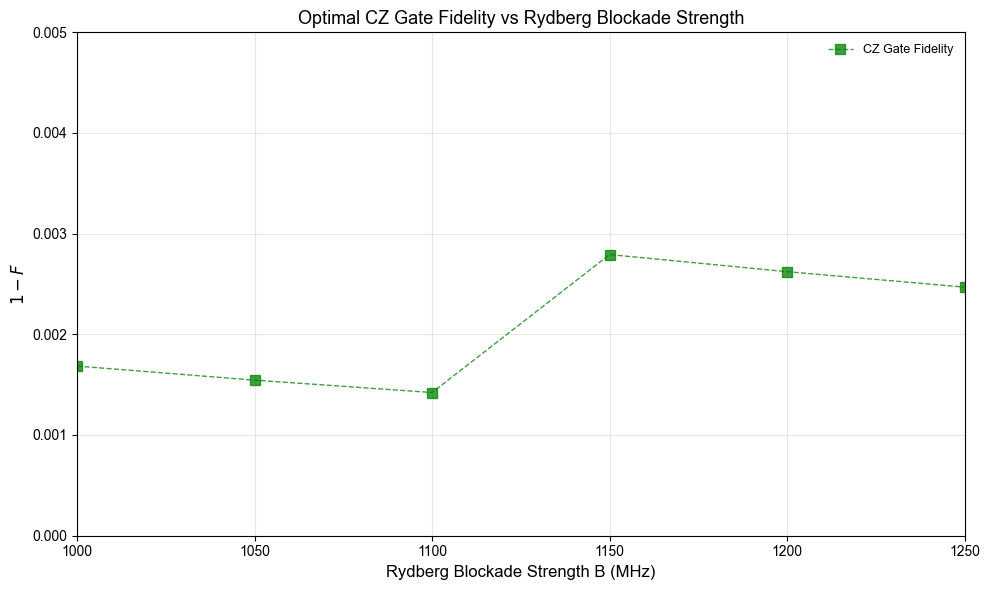


🏆 Best Fidelity Result:
  B = 1100 MHz
  Fidelity = 0.998578
  Infidelity = 1.42e-03


In [37]:
# Apply plotting configuration
plt.rcParams.update(plt_config)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot fidelity vs B using plotting_helpers function
plot_fidelity_vs_parameter(
    ax=ax,
    param_list=df['Rydberg_B_MHz'].values,
    fidelity_list=[df['fidelity'].values],
    legend_list=['CZ Gate Fidelity'],
    title='Optimal CZ Gate Fidelity vs Rydberg Blockade Strength',
    xlabel='Rydberg Blockade Strength B (MHz)',
    ylabel='Fidelity',
    use_infidelity=True,
    log_scale=False,
    ylim=[0, 0.005],
    grid_alpha=0.3,
    show_legend=True
)

# Mark the best fidelity point
best_idx = df['fidelity'].idxmax()
# ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], 1 - df.loc[best_idx, 'fidelity'], 
#         'r*', markersize=15, label=f"Best: F={df.loc[best_idx, 'fidelity']:.6f}")
# ax.legend()

plt.tight_layout()
plt.show()

# Print best result
print(f"\n🏆 Best Fidelity Result:")
print(f"  B = {df.loc[best_idx, 'Rydberg_B_MHz']:.0f} MHz")
print(f"  Fidelity = {df.loc[best_idx, 'fidelity']:.6f}")
print(f"  Infidelity = {1 - df.loc[best_idx, 'fidelity']:.2e}")

### 3. Plot Optimized Parameters vs B

In [38]:
# Parameter bounds
bounds = {
        'T_gate': (0.0, 1.2),
        'tau_ratio': (0.175, 0.175), # Fixed tau_ratio for ARP ( why? )
        'amp_Omega_r': (15*2*np.pi, 50*2*np.pi),
        'amp_Delta_r': (15*2*np.pi, 50*2*np.pi)
    }

d:\Notion_Projects\Notion_Open_Quantum_System\qubits_simulation_codes\Neutral_Atom_Qubit_Simulations\myPkg\plotting_helpers.py:953: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ylim)


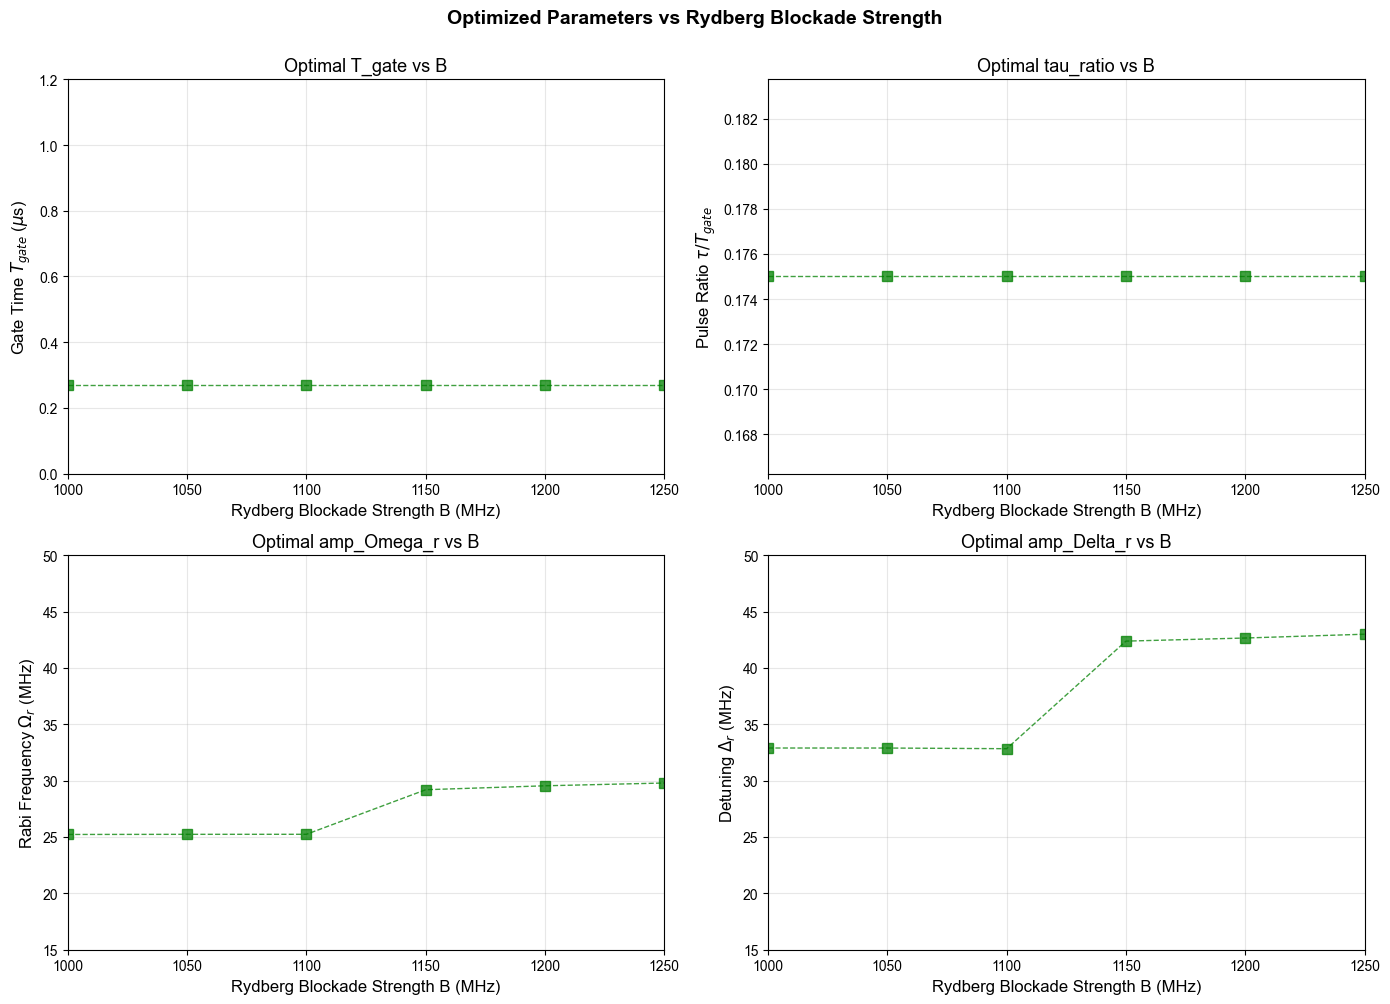

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Parameter information: (column_name, ylabel, need_conversion_to_MHz)
param_info = [
    ('T_gate', r'Gate Time $T_{gate}$ ($\mu$s)', False, axes[0, 0]),
    ('tau_ratio', r'Pulse Ratio $\tau / T_{gate}$', False, axes[0, 1]),
    ('amp_Omega_r', r'Rabi Frequency $\Omega_r$ (MHz)', True, axes[1, 0]),
    ('amp_Delta_r', r'Detuning $\Delta_r$ (MHz)', True, axes[1, 1])
]

for param_name, ylabel, convert_to_MHz, ax in param_info:
    # Convert to appropriate units
    if convert_to_MHz:
        # Convert from rad/μs to MHz
        param_values = df[param_name].values / (2 * np.pi)
        best_val = df.loc[best_idx, param_name] / (2 * np.pi)
    else:
        param_values = df[param_name].values
        best_val = df.loc[best_idx, param_name]
    
    # Use plot_parameter_vs_parameter function
    plot_parameter_vs_parameter(
        ax=ax,
        x_param_list=df['Rydberg_B_MHz'].values,
        y_param_list=[param_values],
        legend_list=[param_name],
        title=f'Optimal {param_name} vs B',
        xlabel='Rydberg Blockade Strength B (MHz)',
        ylabel=ylabel,
        show_legend=False,
        grid_alpha=0.3,
        ylim = bounds[param_name] if not convert_to_MHz else (bounds[param_name][0]/(2*np.pi), bounds[param_name][1]/(2*np.pi))
    )
    
    # Mark best fidelity point
    # ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], best_val, 
    #         'r*', markersize=15, label='Best Fidelity', zorder=5)

plt.suptitle('Optimized Parameters vs Rydberg Blockade Strength', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Observations:**
- Optimized parameters vary smoothly with $B$ except near $B$ = 500 MHz there is a discontinuous jump, which is the same as the fidelity
- In addition, the optimized parameters change quickly from $B$ = 2500 MHz to $B$ = 3000 MHz, which is against our expectation that these optimized parameters should converge as $B$ increases

## Summary and Key Findings

**Overall trends:**
1. **Fidelity vs B:** Optimized fidelity ( infidelity ) generally increases ( decreases ) with increasing blockade strength $B$
2. **Parameter scaling:** $\Omega_r$ and $\Delta_r$ show overall smooth variation with $B$
3. **Anomaly at B = 500 MHz:** Both fidelity and parameters exhibit a discontinuity at this point

**Outstanding questions:**
- **Origin of B = 500 MHz jump:** 
  - Is this an optimization artifact (local minimum)?
  - Or a genuine physical transition in the optimal control regime?
  - Requires: Reoptimization with multiple initial conditions at B = 500 MHz

- **Experimental feasibility:** 
  - Are these optimized parameters achievable in real experiments?
  - How robust are they against noise and parameter fluctuations?

---

**Note:** The following content is almost unrelated to the above.

### 4. Load and Analyze Individual Optimization Monitors

To understand the quality of optimization convergence and investigate potential local minima, we examine detailed optimization histories for specific $B$ values.

**Key diagnostics:**
- Number of iterations required for convergence
- Smoothness of convergence trajectory
- Final fidelity value compared to initial guess

In [25]:
# List available monitor files (now in subdirectories)
# Find all B*MHz subdirectories
b_dirs = sorted(data_dir.glob('B*MHz'))

if b_dirs:
    print(f"📂 Found {len(b_dirs)} B directories:\n")
    monitor_files = []
    for b_dir in b_dirs:
        # Find monitor files in each directory
        monitors_in_dir = list(b_dir.glob('monitor_*.pkl'))
        monitor_files.extend(monitors_in_dir)
        print(f"  - {b_dir.name}: {len(monitors_in_dir)} monitor files")
    
    print(f"\n📄 Total monitor files: {len(monitor_files)}")
else:
    # Fallback: try old structure (monitor files directly in data_dir)
    monitor_files = sorted(data_dir.glob('monitor_B*MHz.pkl'))
    print(f"📂 Found {len(monitor_files)} monitor files (old structure):\n")
    for file in monitor_files:
        print(f"  - {file.name}")

📂 Found 16 B directories:

  - B1000MHz: 1 monitor files
  - B100MHz: 1 monitor files
  - B1250MHz: 1 monitor files
  - B1500MHz: 1 monitor files
  - B1750MHz: 1 monitor files
  - B2000MHz: 1 monitor files
  - B200MHz: 1 monitor files
  - B2500MHz: 1 monitor files
  - B3000MHz: 1 monitor files
  - B300MHz: 1 monitor files
  - B400MHz: 1 monitor files
  - B500MHz: 1 monitor files
  - B600MHz: 1 monitor files
  - B700MHz: 1 monitor files
  - B800MHz: 1 monitor files
  - B900MHz: 1 monitor files

📄 Total monitor files: 16


In [26]:
import pickle
# Select a B value to analyze (e.g., the one with best fidelity)
B_to_analyze = int(df.loc[best_idx, 'Rydberg_B_MHz'])

# Try to find monitor file in new structure (B*MHz subdirectory)
monitor_path = data_dir / f'B{B_to_analyze}MHz' / 'monitor_init0.pkl'

# Fallback to old structure if not found
if not monitor_path.exists():
    monitor_path = data_dir / f'monitor_B{B_to_analyze}MHz.pkl'

if monitor_path.exists():
    # Load monitor (without objective function for inspection)
    with open(monitor_path, 'rb') as f:
        monitor_data = pickle.load(f)
    
    print(f"✅ Loaded monitor for B = {B_to_analyze} MHz")
    print(f"   From: {monitor_path.relative_to(data_dir)}\n")
    
    # Extract best result
    history = monitor_data.history
    param_names = monitor_data.param_names
    
    # Find best iteration
    best_iter = np.argmax(history['fidelity'])
    
    print(f"📊 Optimization Summary:")
    print(f"  Total iterations: {len(history['iteration'])}")
    print(f"  Best iteration: {history['iteration'][best_iter]}")
    print(f"  Best fidelity: {history['fidelity'][best_iter]:.6f}")
    print(f"  Best infidelity: {history['infidelity'][best_iter]:.2e}")
    print(f"\n  Best parameters:")
    for name in param_names:
        if 'amp' in name:
            print(f"    {name}: {history[name][best_iter]/(2*np.pi):.4f} MHz")
        else:
            print(f"    {name}: {history[name][best_iter]:.4f}")
else:
    print(f"❌ Monitor file not found: {monitor_path}")
    print(f"   Tried: B{B_to_analyze}MHz/monitor_init0.pkl")
    print(f"   Also tried: monitor_B{B_to_analyze}MHz.pkl")

✅ Loaded monitor for B = 3000 MHz
   From: B3000MHz\monitor_init0.pkl

📊 Optimization Summary:
  Total iterations: 96
  Best iteration: 95
  Best fidelity: 0.999385
  Best infidelity: 6.15e-04

  Best parameters:
    T_gate: 0.2700
    tau_ratio: 0.1750
    amp_Omega_r: 32.3289 MHz
    amp_Delta_r: 40.5767 MHz


In [33]:
print(monitor_data.history['amp_Omega_r'][0] / (2*np.pi))
print(monitor_data.history['amp_Delta_r'][0] / (2*np.pi))

32.300000000000004
47.150000000000006


### 5. Plot Optimization Convergence

Visualize the optimization trajectory to assess convergence quality:
- **Fidelity evolution:** Should show monotonic improvement (or at least no significant degradation)
- **Parameter evolution:** Reveals how the optimizer explores the parameter space
- **Convergence speed:** Indicates whether the optimization landscape is well-behaved

**Interpretation tips:**
- Smooth convergence suggests a well-conditioned optimization problem
- Erratic behavior may indicate multiple local optima or numerical issues
- Plateaus followed by jumps can reveal escape from local minima

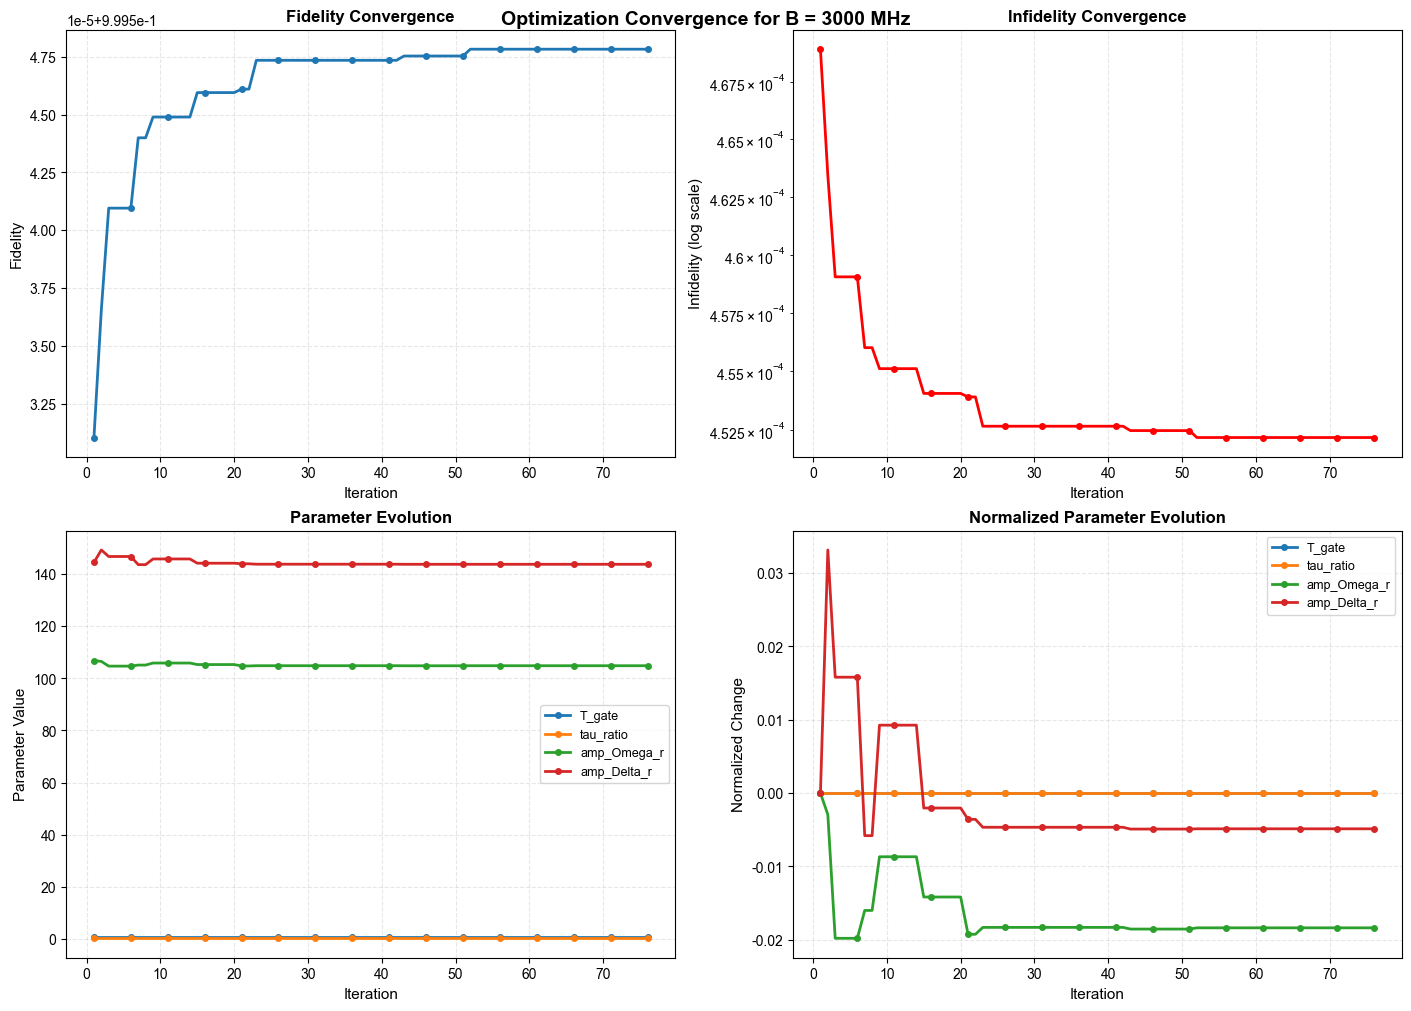

In [15]:
# Plot convergence using plotting_helpers function
fig, axes = plot_optimization_convergence(history, param_names, figsize=(14, 10))

# Add title with B value
fig.suptitle(f'Optimization Convergence for B = {B_to_analyze} MHz', 
             fontsize=14, fontweight='bold', y=0.995)

plt.show()